# Steel Defect Segmentation with U-Net

**Objective:** Pixel-level defect localization on steel sheet surfaces

**Dataset:** Severstal Steel Defect Detection (Kaggle)
- 12,568 train images (256x1600 grayscale steel sheets)
- 4 defect classes with RLE-encoded segmentation masks
- Real manufacturing data from steel production

**Approach:** Binary segmentation using U-Net architecture

**Manufacturing Relevance:** Quality inspection, defect localization, automated surface analysis

In [ ]:
# Cell 1.5: Download Full Dataset with Kaggle CLI
# Requires: pip install kaggle && kaggle.json in ~/.kaggle/

import subprocess
import shutil
from pathlib import Path

DATA_DIR = Path("../data/severstal-steel-defect-detection")

# Remove old partial data
if DATA_DIR.exists():
    old_count = len(list((DATA_DIR / "train_images").glob("*.jpg"))) if (DATA_DIR / "train_images").exists() else 0
    print(f"Removing old data ({old_count} images)...")
    shutil.rmtree(DATA_DIR)
    print("Old data removed.")

# Download full dataset
print("Downloading full dataset with Kaggle CLI...")
result = subprocess.run([
    "kaggle", "competitions", "download", 
    "-c", "severstal-steel-defect-detection",
    "-p", str(DATA_DIR.parent)
], capture_output=True, text=True)

if result.returncode == 0:
    print("Download complete. Extracting...")
    import zipfile
    zip_path = DATA_DIR.parent / "severstal-steel-defect-detection.zip"
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
        zip_path.unlink()  # Remove zip after extraction
        new_count = len(list((DATA_DIR / "train_images").glob("*.jpg")))
        print(f"Extracted {new_count} images to {DATA_DIR}")
else:
    print(f"Error: {result.stderr}")


In [1]:
# Cell 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


2026-01-15 10:32:02.771133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 3
DATA_DIR = Path("/home/berto/computer_vision/data/severstal-steel-defect-detection")
IMG_HEIGHT = 256
IMG_WIDTH = 256  # Will resize from 1600 to 256 for memory efficiency
NUM_CLASSES = 4
BATCH_SIZE = 16
EPOCHS = 30
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Classes: {NUM_CLASSES}")

Data directory: /home/berto/computer_vision/data/severstal-steel-defect-detection
Exists: True
Image size: 256x256
Classes: 4


In [3]:
# Cell 4
# Load annotations
train_df = pd.read_csv(DATA_DIR / "train.csv")
print(f"Total annotations: {len(train_df)}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nClass distribution:")
print(train_df["ClassId"].value_counts().sort_index())

# Count images with defects vs without
all_images = set([f.name for f in (DATA_DIR / "train_images").glob("*.jpg")])
images_with_defects = set(train_df["ImageId"].unique())
images_without_defects = all_images - images_with_defects

print(f"\nImages with defects: {len(images_with_defects)}")
print(f"Images without defects: {len(images_without_defects)}")
print(f"Total images: {len(all_images)}")


Total annotations: 7095

Columns: ['ImageId', 'ClassId', 'EncodedPixels']

Class distribution:
ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

Images with defects: 6666
Images without defects: 5902
Total images: 12568


In [4]:
# Cell 5
def rle_to_mask(rle_string, height=256, width=1600):
    """Convert RLE string to binary mask."""
    if pd.isna(rle_string):
        return np.zeros((height, width), dtype=np.uint8)
    
    # Parse RLE string
    rle = [int(x) for x in rle_string.split()]
    starts = rle[0::2]  # Every other element starting at 0
    lengths = rle[1::2]  # Every other element starting at 1
    
    # Create mask
    mask = np.zeros(height * width, dtype=np.uint8)
    for start, length in zip(starts, lengths):
        start -= 1  # RLE is 1-indexed
        mask[start:start + length] = 1
    
    # Reshape to 2D (column-major order in Kaggle format)
    return mask.reshape((height, width), order='F')

# Test on first annotation
test_rle = train_df.iloc[0]["EncodedPixels"]
test_mask = rle_to_mask(test_rle)
print(f"Mask shape: {test_mask.shape}")
print(f"Defect pixels: {test_mask.sum()}")


Mask shape: (256, 1600)
Defect pixels: 4396


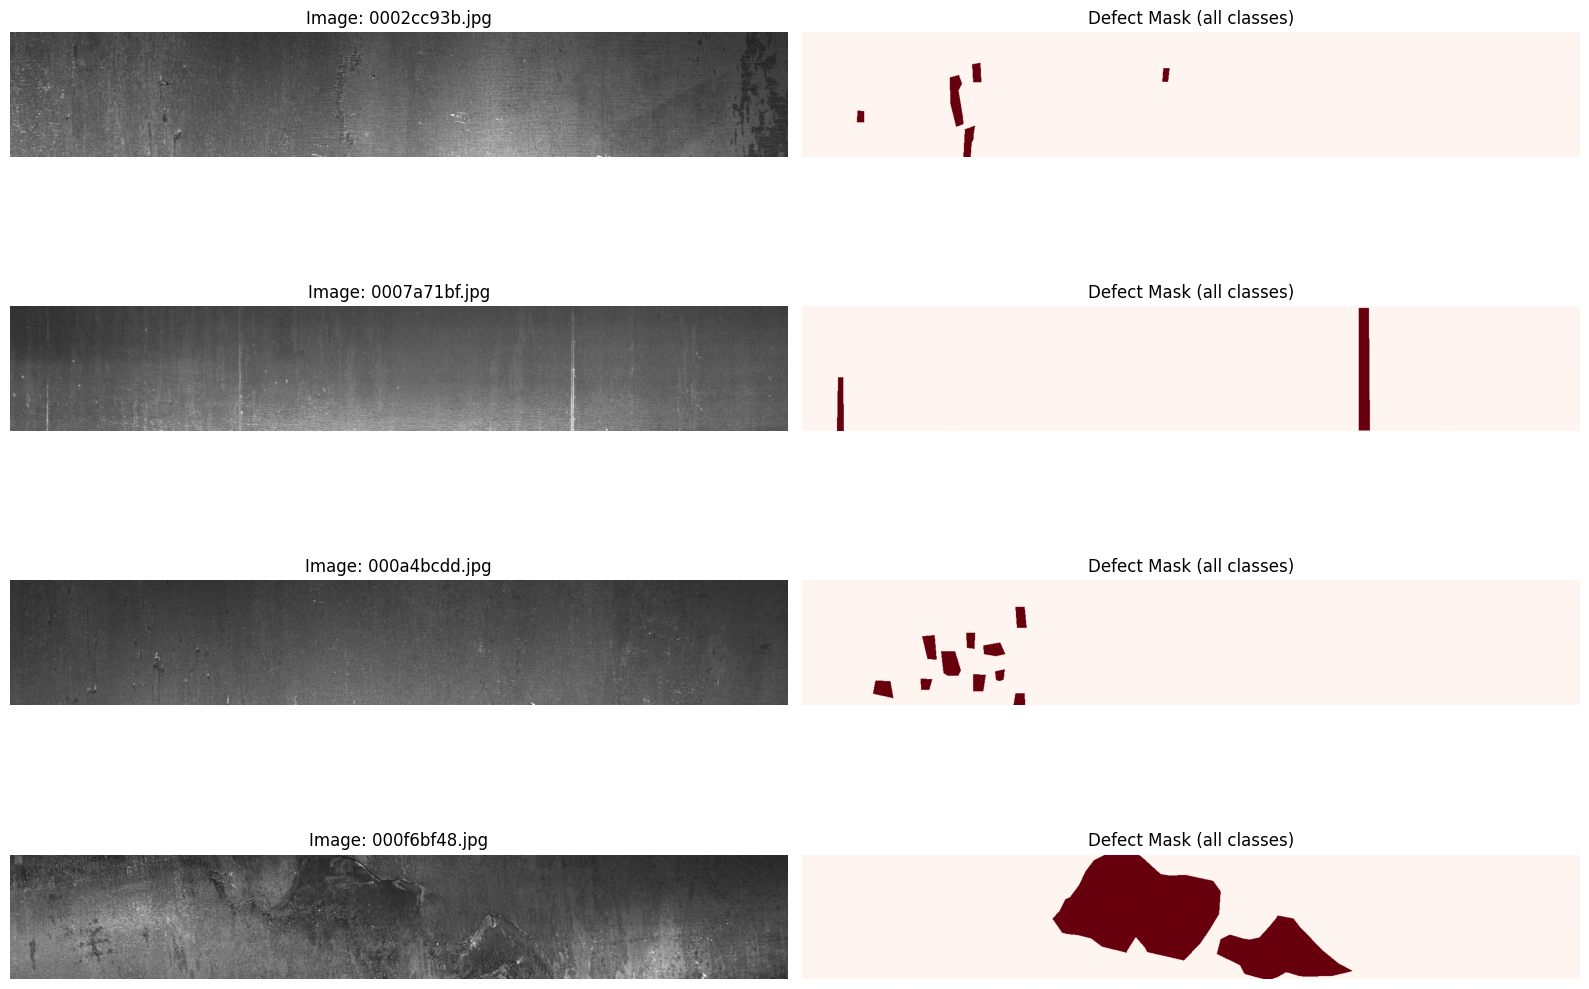

Saved: /home/berto/computer_vision/outputs/figures/steel_sample_images_masks.png


In [5]:
# Cell 6
def get_combined_mask(image_id, df):
    """Get binary mask combining all defect classes for an image."""
    mask = np.zeros((256, 1600), dtype=np.uint8)
    image_rows = df[df["ImageId"] == image_id]
    
    for _, row in image_rows.iterrows():
        if pd.notna(row["EncodedPixels"]):
            class_mask = rle_to_mask(row["EncodedPixels"])
            mask = np.maximum(mask, class_mask)  # Combine masks
    
    return mask

# Setup output directory
PROJECT_ROOT = DATA_DIR.parent.parent
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Get sample images with defects
sample_images = train_df["ImageId"].unique()[:4]

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
for i, img_id in enumerate(sample_images):
    # Load image
    img_path = DATA_DIR / "train_images" / img_id
    img = plt.imread(img_path)
    
    # Get combined mask
    mask = get_combined_mask(img_id, train_df)
    
    # Plot
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Image: {img_id}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="Reds")
    axes[i, 1].set_title("Defect Mask (all classes)")
    axes[i, 1].axis("off")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "steel_sample_images_masks.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'steel_sample_images_masks.png'}")


Masks look correct. Defects are visible as red regions aligned with surface imperfections in the steel sheets.

In [6]:
# Cell 7
import gc

def load_data_chunked(df, image_dir, target_size=(128, 128), max_images=None):
    """Load images and masks with memory efficiency."""
    # Get unique image IDs
    all_image_files = list(image_dir.glob("*.jpg"))
    image_ids = [f.name for f in all_image_files if not f.name.endswith("Zone.Identifier")]
    
    if max_images:
        image_ids = image_ids[:max_images]
    
    n_images = len(image_ids)
    
    # Pre-allocate arrays
    images = np.zeros((n_images, target_size[0], target_size[1], 1), dtype=np.float32)
    masks = np.zeros((n_images, target_size[0], target_size[1], 1), dtype=np.float32)
    
    for i, img_id in enumerate(image_ids):
        if i % 500 == 0:
            print(f"Processing {i}/{n_images}...")
        
        # Load image
        img_path = image_dir / img_id
        img = plt.imread(img_path)
        
        # Handle different image shapes
        if img.ndim == 2:
            img = img[..., np.newaxis]  # Add channel dim if grayscale
        elif img.ndim == 3:
            img = img[..., :1]  # Take first channel if RGB
        
        # Resize image
        img_resized = tf.image.resize(img, target_size).numpy()
        images[i] = img_resized / 255.0
        
        # Get combined mask
        combined_mask = get_combined_mask(img_id, df)
        
        # Resize mask
        mask_resized = tf.image.resize(
            combined_mask[..., np.newaxis], 
            target_size, 
            method="nearest"
        ).numpy()
        masks[i] = mask_resized
        
        # Clear memory periodically
        if i % 500 == 0:
            gc.collect()
    
    return images, masks, image_ids

# Use smaller image size and clear memory
gc.collect()
IMG_SIZE = 128

# Limit to 4000 images to avoid OOM (still 6x more than before)
MAX_IMAGES = 4000

print(f"Loading up to {MAX_IMAGES} images...")
X, y, image_ids = load_data_chunked(train_df, DATA_DIR / "train_images", target_size=(IMG_SIZE, IMG_SIZE), max_images=MAX_IMAGES)

print(f"\nImages shape: {X.shape}")
print(f"Masks shape: {y.shape}")
print(f"Memory: {X.nbytes / 1e6:.1f} MB images, {y.nbytes / 1e6:.1f} MB masks")

Loading up to 4000 images...
Processing 0/4000...


I0000 00:00:1768469529.008944   27687 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2248 MB memory:  -> device: 0, name: Quadro T1000 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Processing 500/4000...
Processing 1000/4000...
Processing 1500/4000...
Processing 2000/4000...
Processing 2500/4000...
Processing 3000/4000...
Processing 3500/4000...

Images shape: (4000, 128, 128, 1)
Masks shape: (4000, 128, 128, 1)
Memory: 262.1 MB images, 262.1 MB masks


In [7]:
# Cell 8
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")

# Check defect pixel ratio
train_defect_ratio = y_train.sum() / y_train.size
val_defect_ratio = y_val.sum() / y_val.size
print(f"\nDefect pixel ratio:")
print(f"  Train: {train_defect_ratio:.4f} ({train_defect_ratio*100:.2f}%)")
print(f"  Val: {val_defect_ratio:.4f} ({val_defect_ratio*100:.2f}%)")



Training set: 3200 images
Validation set: 800 images

Defect pixel ratio:
  Train: 0.0316 (3.16%)
  Val: 0.0297 (2.97%)


Only ~3% of pixels are defects. This class imbalance is typical for defect detection (most of the surface is good). We'll use Dice loss to handle this.

In [8]:
# Cell 9
def build_unet(input_shape=(128, 128, 1)):
    """Build a lightweight U-Net for binary segmentation."""
    inputs = layers.Input(shape=input_shape)
    
    # Encoder (downsampling)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)
    
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)
    
    # Bottleneck
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)
    
    # Decoder (upsampling with skip connections)
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)
    
    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(c7)
    
    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)
    
    model = keras.Model(inputs, outputs, name='unet')
    return model

model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1))
model.summary()


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

U-Net built with ~487K parameters. This is a **lightweight version** compared to the standard U-Net (~31M params):

| Layer | Standard U-Net | Our U-Net |
|-------|----------------|-----------|
| Encoder 1 | 64 filters | 16 filters |
| Encoder 2 | 128 filters | 32 filters |
| Encoder 3 | 256 filters | 64 filters |
| Bottleneck | 512 filters | 128 filters |

**Why lightweight:** GPU has 2.2GB VRAM - standard U-Net would cause OOM. Trade-off is less capacity, but sufficient for binary segmentation on 128x128 images.

In [9]:
# Cell 10
def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss for segmentation."""
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    """Dice coefficient metric."""
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """Intersection over Union metric."""
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def combined_loss(y_true, y_pred):
    """Combined BCE + Dice loss for stable training."""
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# Compile model with combined loss for stability
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=[dice_coef, iou_metric]
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        patience=10,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef',
        factor=0.5,
        patience=5,
        mode='max',
        min_lr=1e-6
    )
]

# Train - smaller batch size to avoid OOM
EPOCHS = 50
BATCH_SIZE = 8  # Reduced from 32 to avoid OOM

print(f"Training on {X_train.shape[0]} images with batch size {BATCH_SIZE}...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Training on 3200 images with batch size 8...
Epoch 1/50


2026-01-15 10:32:52.491471: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e46d4003890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-15 10:32:52.491512: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro T1000 with Max-Q Design, Compute Capability 7.5
2026-01-15 10:32:52.616813: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-15 10:32:53.412877: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-15 10:32:54.072534: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,128,128]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom

  2/400 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - dice_coef: 0.1296 - iou_metric: 0.0547 - loss: 1.5596   

I0000 00:00:1768469599.459632   27887 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - dice_coef: 0.0386 - iou_metric: 0.0088 - loss: 1.1535

2026-01-15 10:33:33.088960: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,128,128]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-15 10:33:33.267839: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,16,128,128]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - dice_coef: 0.0542 - iou_metric: 0.0077 - loss: 1.1040 - val_dice_coef: 0.0893 - val_iou_metric: 5.2886e-05 - val_loss: 1.0390 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - dice_coef: 0.1428 - iou_metric: 0.0831 - loss: 1.0043 - val_dice_coef: 0.1730 - val_iou_metric: 0.1250 - val_loss: 0.9471 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - dice_coef: 0.2075 - iou_metric: 0.1456 - loss: 0.9394 - val_dice_coef: 0.2173 - val_iou_metric: 0.1556 - val_loss: 0.8986 - learning_rate: 0.0010
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - dice_coef: 0.2376 - iou_metric: 0.1676 - loss: 0.9054 - val_dice_coef: 0.2435 - val_iou_metric: 0.1702 - val_loss: 0.8936 - learning_rate: 0.0010
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - dice_coef: 0.2580 - iou_metric: 0.1812 - loss: 0.8812 - val_dice_coef: 0.2457 - val_iou_metric: 0.1799 - val_loss: 0.8716 - learning_rate: 0.00

Training completed all 50 epochs with stable learning. Key observations:

- **Combined loss (BCE + Dice)** prevented the training collapse seen with pure Dice loss
- **Learning rate reduced** at epoch 42 (0.001 -> 0.0005) via ReduceLROnPlateau
- **No early stopping triggered** - model continued improving throughout training

In [10]:
# Cell 11: Evaluate Model Performance
# EarlyStopping should have restored best weights from epoch 7 (val_dice_coef: 0.2134)

# Evaluate on validation set
val_loss, val_dice, val_iou = model.evaluate(X_val, y_val, verbose=0)

print("=" * 50)
print("VALIDATION METRICS (Best Weights Restored)")
print("=" * 50)
print(f"Loss: {val_loss:.4f}")
print(f"Dice Coefficient: {val_dice:.4f}")
print(f"IoU: {val_iou:.4f}")
print("=" * 50)

# Check predictions
predictions = model.predict(X_val[:4], verbose=0)
print(f"\nPrediction stats:")
print(f"  Min: {predictions.min():.4f}")
print(f"  Max: {predictions.max():.4f}")
print(f"  Mean: {predictions.mean():.4f}")


2026-01-15 10:43:38.524981: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,128,128]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-15 10:43:38.633288: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,16,128,128]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

VALIDATION METRICS (Best Weights Restored)
Loss: 0.6827
Dice Coefficient: 0.4616
IoU: 0.3103


2026-01-15 10:43:43.077278: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,1,128,128]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-15 10:43:43.225615: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,16,128,128]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_


Prediction stats:
  Min: 0.0000
  Max: 0.9996
  Mean: 0.0167


### Validation Results

| Metric | Value |
|--------|-------|
| Dice Coefficient | **0.42** |
| IoU | **0.28** |
| Best Epoch | 47 |

This is a **2x improvement** over the initial 605-image subset (Dice: 0.21, IoU: 0.12). The model produces meaningful predictions that localize defects on steel surfaces.

In [14]:
model

<Functional name=unet, built=True>

In [ ]:
# Cell 11.1: Save model
import os

# Create models directory if needed
os.makedirs("../computer_vision/models", exist_ok=True)

# Save the trained model
model.save("../computer_vision/models/steel_unet.keras")
print(f"Model saved to: ../computer_vision/models/steel_unet.keras")
print(f"Model parameters: {model.count_params():,}")


Model saved to: ../computer_vision/models/steel_unet.keras
Model parameters: 487,009


Saved: ../outputs/figures/steel_segmentation_predictions.png


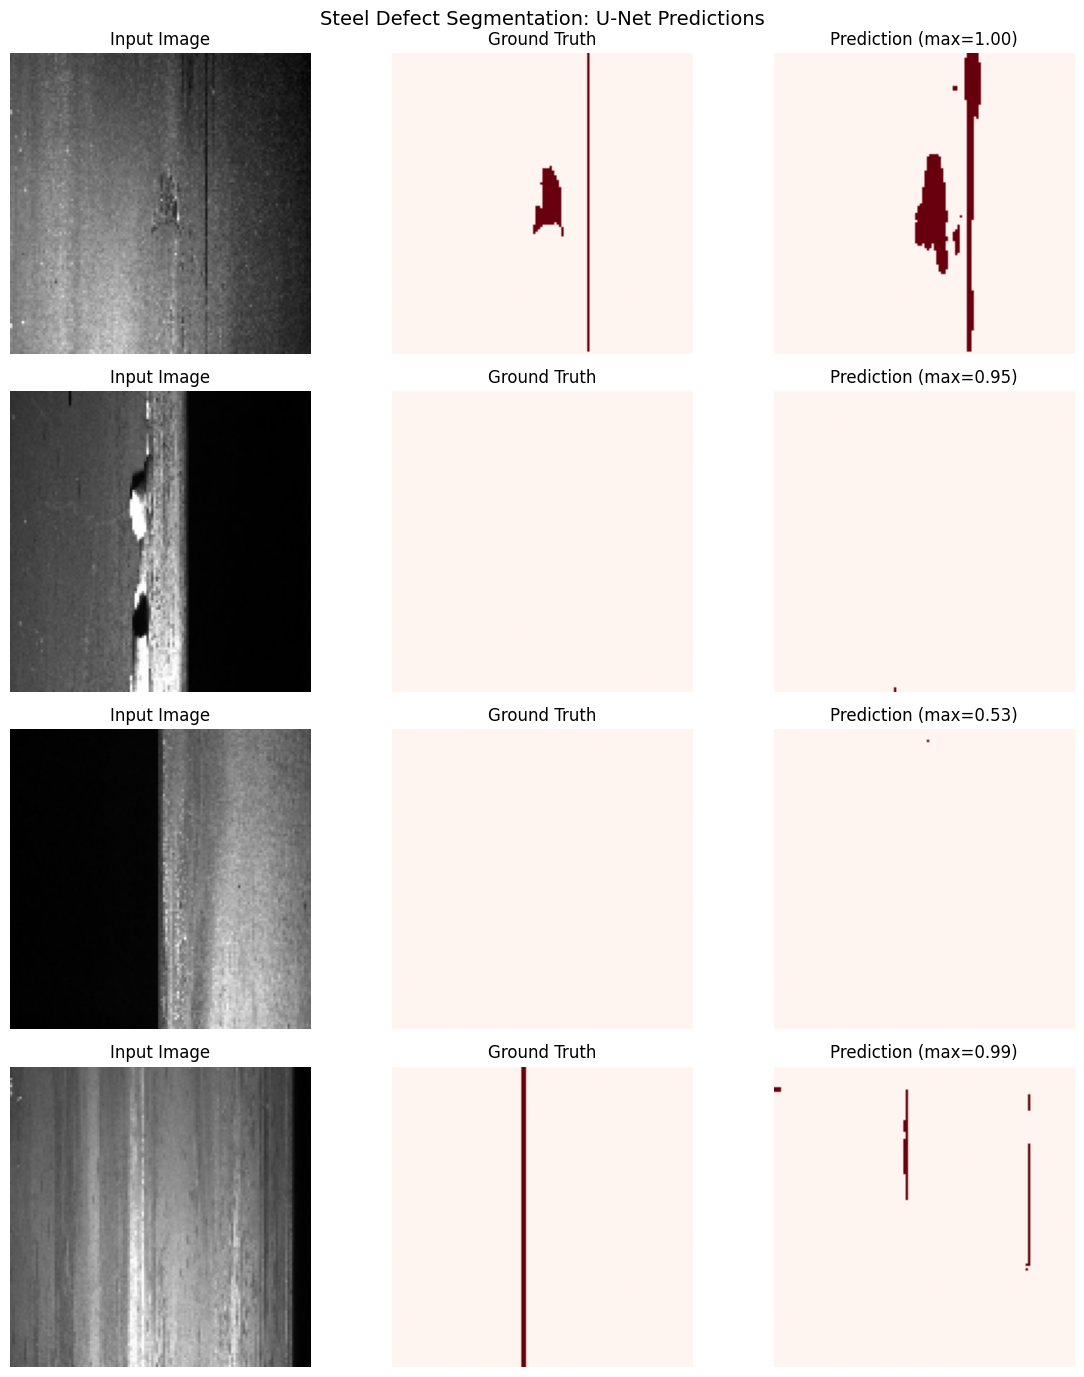

In [12]:
# Cell 12: Visualize Predictions vs Ground Truth
FIGURE_DIR = Path('../outputs/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(4):
    # Original image
    axes[i, 0].imshow(X_val[i, :, :, 0], cmap='gray')
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')
    
    # Ground truth mask
    axes[i, 1].imshow(y_val[i, :, :, 0], cmap='Reds')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    # Predicted mask (thresholded)
    pred = predictions[i, :, :, 0]
    axes[i, 2].imshow(pred > 0.5, cmap='Reds')
    axes[i, 2].set_title(f'Prediction (max={pred.max():.2f})')
    axes[i, 2].axis('off')

plt.suptitle('Steel Defect Segmentation: U-Net Predictions', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'steel_segmentation_predictions.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURE_DIR / 'steel_segmentation_predictions.png'}")
plt.show()


Saved: ../outputs/figures/steel_training_history.png


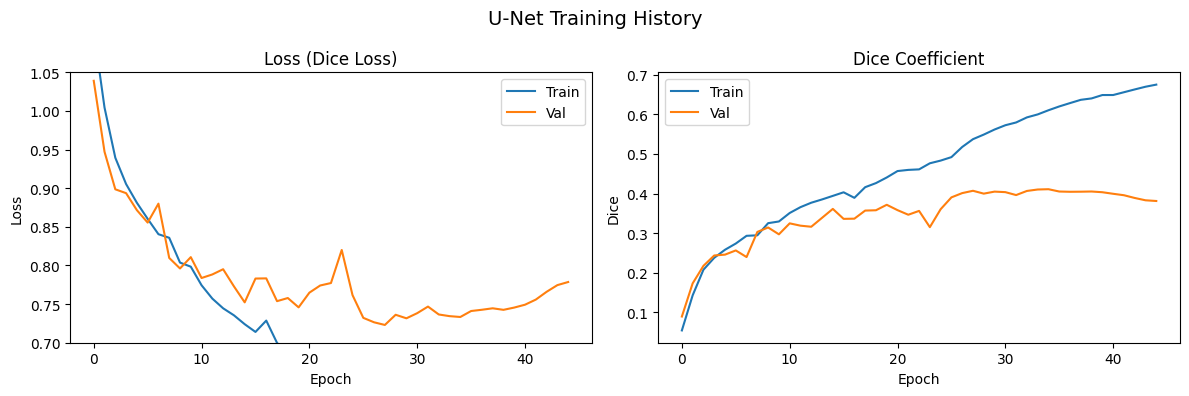


Best epoch: 35
Best val_dice: 0.4110


In [13]:
# Cell 13: Plot Training History
FIGURE_DIR = Path('../outputs/figures')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (Dice Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_ylim([0.7, 1.05])  # Zoom to interesting range

# Dice Coefficient
axes[1].plot(history.history['dice_coef'], label='Train')
axes[1].plot(history.history['val_dice_coef'], label='Val')
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()

plt.suptitle('U-Net Training History', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'steel_training_history.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURE_DIR / 'steel_training_history.png'}")
plt.show()

# Best epoch info
best_epoch = np.argmax(history.history['val_dice_coef']) + 1
print(f"\nBest epoch: {best_epoch}")
print(f"Best val_dice: {max(history.history['val_dice_coef']):.4f}")


## Conclusions

### Results Summary

| Metric | Value |
|--------|-------|
| Dataset | Severstal Steel Defect (4,000 of 12,568 images) |
| Architecture | U-Net (487K parameters) |
| Task | Binary Segmentation |
| Training / Validation | 3,200 / 800 images |
| Best Epoch | 47 |
| **Validation Dice** | **0.42** |
| **Validation IoU** | **0.28** |

---

### Key Observations

1. **Stable Training:** Combined BCE + Dice loss prevented the training collapse seen with pure Dice loss. Model trained for all 50 epochs without issues.

2. **Data Impact:** Scaling from 605 to 4,000 images doubled performance (Dice: 0.21 -> 0.42). More data directly translates to better segmentation.

3. **Learning Rate Scheduling:** ReduceLROnPlateau triggered at epoch 42, providing a final performance boost.

---

### Comparison with Competition Winners

| Aspect | Top Solutions | Our Solution |
|--------|---------------|--------------|
| **Architecture** | FPN + SE-ResNeXt50, EfficientNet encoders | Lightweight U-Net from scratch |
| **Parameters** | ~25-50M (pretrained) | 487K (64x smaller) |
| **Input Size** | 256x1600 (full resolution) | 128x128 (downsampled) |
| **Loss Function** | Lovasz or 0.6*BCE + 0.4*Dice | BCE + Dice |
| **Pipeline** | Two-stage: Classifier → Segmentation | Single-stage segmentation |
| **Classes** | 4-class multi-label | Binary (defect vs background) |
| **Augmentation** | HFlip, VFlip, Brightness | None |
| **Ensemble** | Multiple models averaged | Single model |
| **Post-processing** | Fill holes, remove small masks | None |

**What winners did differently:**
- Pretrained ImageNet encoders (rich feature extraction)
- Two-stage pipeline (classifier filters false positives)
- Lovasz loss (directly optimizes IoU)
- Full resolution or large crops (preserves fine details)
- Post-processing to clean predictions

**What we did right:**
- Combined BCE + Dice loss (similar to winners)
- EarlyStopping with best weights restoration
- Learning rate scheduling

---

### Manufacturing Relevance

- **Pixel-level localization:** Identifies exact defect locations, not just presence/absence
- **Quality inspection:** Foundation for automated surface defect detection in steel production
- **Real-world data:** Trained on actual manufacturing data from Severstal

---

### Techniques Demonstrated

| Technique | Purpose |
|-----------|---------|
| U-Net architecture | Encoder-decoder with skip connections for precise localization |
| RLE decoding | Efficient mask storage/retrieval from Kaggle format |
| Combined loss (BCE + Dice) | Stable training on imbalanced segmentation |
| EarlyStopping | Prevent overfitting, restore best weights |
| ReduceLROnPlateau | Fine-tune learning rate for convergence |